## Averaged flows


In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
import trackpy as tp

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


# image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\*.tif")
image_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Pos6\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

In [2]:
image_list[0],image_list[-1],

('C:\\Users\\victo\\OneDrive - BGU\\DATA\\Hacat\\6 Wells _5x_15min\\_1\\Pos6\\img_channel000_position006_time000000000_z000.tif',
 'C:\\Users\\victo\\OneDrive - BGU\\DATA\\Hacat\\6 Wells _5x_15min\\_1\\Pos6\\img_channel000_position006_time000000186_z000.tif')

In [2]:
df_plus, df_minus = image_list_to_defect_list(image_list[120:130])

In [4]:
%matplotlib qt
plot_flow_and_nematics(image_list, 150, flow_sigma=15, ori_sigma=21, 
                    #    box=[500,500,800,900], 
                       bg=False,)

In [5]:
first_frame = 120
last_frame = len(image_list)
df_list = Parallel(n_jobs=5)(delayed(lambda img: analyze_defects(img, sigma=15))
    (
    cv2.imread(img)[:,:,0]
    ) for img in image_list[first_frame:last_frame])

for i, df in enumerate(df_list):
    df[1]['frame'] = i
    df[2]['frame'] = i

# Concatenate the DataFrames
df_plus = pd.concat([df[1] for df in df_list], ignore_index=True)
df_minus = pd.concat([df[2] for df in df_list], ignore_index=True)

In [20]:
search_range = 60
tplus = tp.link_df(df_plus, search_range, memory=3)
tminus = tp.link_df(df_minus, search_range, memory=3)

Frame 86: 136 trajectories present.


In [25]:
t_all = pd.concat([tplus, tminus], ignore_index=True)
t_all.rename(columns={'x':'x_img', 'y':'y_img',
                        'x_ind':'x_img1', 'y_ind':'y_img1',
                        'frame':'FRAME', 'particle':'TRACK_ID',
                   }, inplace=True)
t_all["POSITION_T"] = t_all["FRAME"]
t_all.to_csv(r"C:\Users\victo\OneDrive - BGU\DATA\Hacat\6 Wells _5x_15min\_1\Nematics\PlusAndMinusTM.csv")

In [ ]:
plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Defects\PlusAndMinusTM.csv")
plus_minus_df.tail()

,Unnamed: 0,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,...,CONTRAST_CH1,SNR_CH1,x_img,y_img,x_img1,y_img1,ang1,ang2,ang3,charge
93581,46890,ID340198,340198,4380.0,79.719513,534.0,878.0,0.0,339.0,339,...,0.916894,1.575584,1144.131149,13.135322,1145.0,13.0,-3.078761,1.193805,-1.130973,-0.5
93582,46891,ID340193,340193,4313.0,81.421516,164.0,839.0,0.0,339.0,339,...,0.973672,1.625018,222.609035,110.270194,222.0,111.0,2.324779,-1.822124,0.376991,-0.5
93583,46892,ID340192,340192,NaN,81.421516,765.0,836.0,0.0,339.0,339,...,0.973672,1.625018,1719.459819,117.742108,1720.0,119.0,-2.953097,-1.068142,1.256637,-0.5
93584,46893,ID340195,340195,NaN,81.421516,754.0,855.0,0.0,339.0,339,...,0.973672,1.625018,1692.063216,70.419990,1693.0,70.0,-1.507964,0.125664,2.199115,-0.5
93585,46894,ID340194,340194,4312.0,81.421516,683.0,854.0,0.0,339.0,339,...,0.973672,1.625018,1515.230594,72.910628,1516.0,72.0,-2.576106,-0.691150,1.319469,-0.5


In [15]:
df_plus.keys()

Index(['charge', 'x', 'y', 'x_ind', 'y_ind', 'ang1', 'ang2', 'ang3', 'frame'], dtype='object')

In [18]:
t.rename(columns={'x':'x_img', 'y':'y_img',
                        'x_ind':'x_img1', 'y_ind':'y_img1',
                        'frame':'FRAME', 'particle':'TRACK_ID',
                   }, inplace=True)

In [19]:
t

,charge,x_img,y_img,x_img1,y_img1,ang1,ang2,ang3,FRAME,TRACK_ID,x_rel,y_rel
0,0.5,232.0,12.0,232,12,2.764602,NaN,NaN,0,0,0.0,0.0
1,0.5,913.0,21.0,913,21,-2.136283,NaN,NaN,0,1,0.0,0.0
82,0.5,201.0,647.0,201,647,-0.628319,NaN,NaN,0,2,0.0,0.0
83,0.5,1313.0,658.0,1313,658,2.701770,NaN,NaN,0,3,0.0,0.0
84,0.5,1249.0,662.0,1249,662,-0.376991,NaN,NaN,0,4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11448,0.5,1242.0,1084.0,1242,1084,-2.890265,NaN,NaN,86,1488,-3.0,-3.0
11449,0.5,614.0,1089.0,614,1089,-2.827433,NaN,NaN,86,1458,-16.0,42.0
11450,0.5,555.0,1101.0,555,1101,2.010619,NaN,NaN,86,115,20.0,141.0
11419,0.5,1159.0,890.0,1159,890,2.513274,NaN,NaN,86,1484,3.0,-4.0


In [13]:
plus_minus_df.keys()

Index(['Unnamed: 0', 'LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X',
       'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS',
       'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1',
       'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1',
       'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'CONTRAST_CH1', 'SNR_CH1',
       'x_img', 'y_img', 'x_img1', 'y_img1', 'ang1', 'ang2', 'ang3', 'charge'],
      dtype='object')

Text(0, 0.5, '$Number ~of ~defects$')

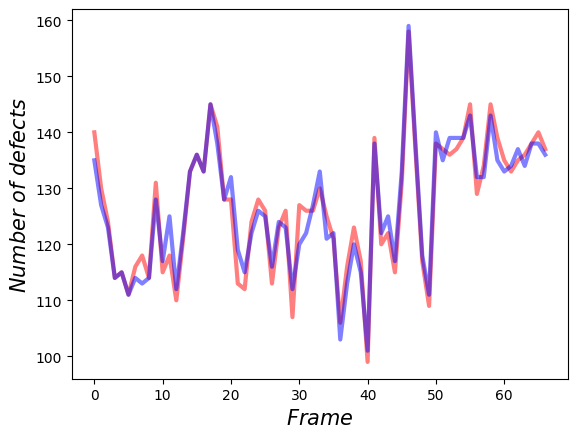

In [6]:
%matplotlib inline
df_plus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="r")
df_minus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="b")

plt.xlabel("$Frame$", fontsize=15)
plt.ylabel("$Number ~of ~defects$", fontsize=15)

# TODO add tracking of defects and detect pairs

In [5]:
%matplotlib qt
search_range = 60
t = tp.link_df(df_plus, search_range, memory=3)
tp.plot_traj(t)

Frame 86: 137 trajectories present.


<Axes: xlabel='x [px]', ylabel='y [px]'>

In [6]:
t["x_rel"] = t.groupby('particle')['x'].transform(lambda x: x-x.iloc[0])
t["y_rel"] = t.groupby('particle')['y'].transform(lambda x: x-x.iloc[0])

C:\Users\victo\AppData\Local\Temp\ipykernel_32748\1678802844.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', t['particle'].nunique())


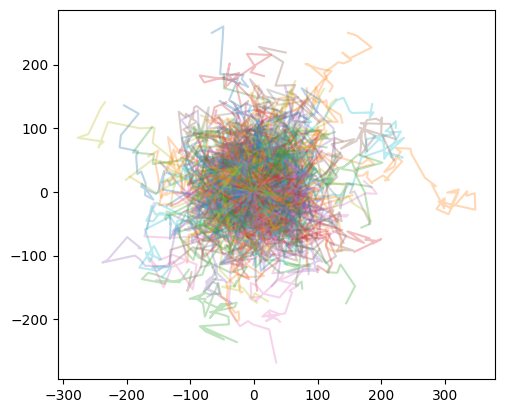

In [7]:
%matplotlib inline
# Create a color map
colors = plt.cm.get_cmap('jet', t['particle'].nunique())
# Loop through each unique particle and plot its trajectory
for i, particle in enumerate(t['particle'].unique()):
    particle_data = t[t['particle'] == particle]
    plt.plot(particle_data['x_rel'], particle_data['y_rel'], alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')


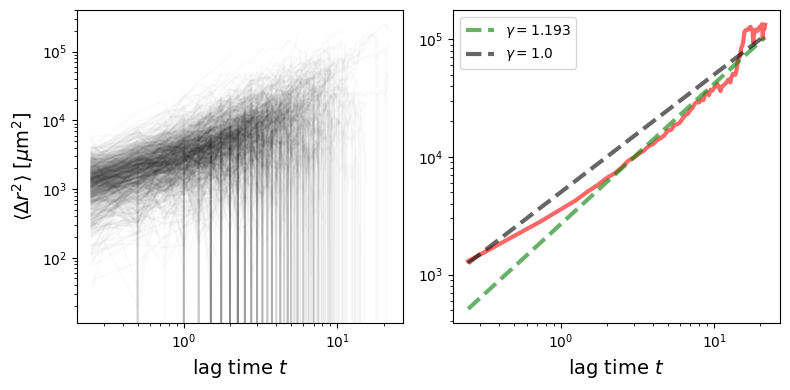

In [8]:
from scipy.optimize import curve_fit
# Define a power law function for fitting
def power_law(x, a, b):
    return a * x**b

px_size = 1.5
frames_per_hour = 4

tm = tp.filter_stubs(t, 5)
im = tp.imsd(tm, px_size, frames_per_hour)  # microns per pixel = 100/285., frames per hour = 24

em = tp.emsd(tm, px_size, frames_per_hour)

# fit a power law function
weights = em**1
params, covariance = curve_fit(power_law, em.index, em, sigma=weights)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(8, 4))
ax1.plot(im.index, im, 'k-', alpha=0.02)  # black lines, semitransparent
ax2.plot(em.index, em, 'r', linewidth=3, alpha=0.6)
ax2.plot(em.index, power_law(em.index, *params), "--g", linewidth=3, alpha=0.6, label="$\gamma=%.5s$" % params[1])
ax2.plot(em.index, power_law(em.index, *[5e3,   1.]), "--k", linewidth=3, alpha=0.6, label="$\gamma=%.5s$" % 1.)

ax1.set_ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]', fontsize=14)

for ax in [ax1, ax2]:    
    ax.set_xlabel('lag time $t$', fontsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()
plt.legend()

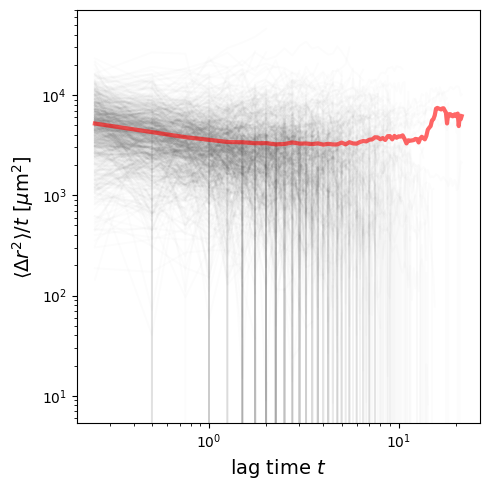

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(im.index, im.div(im.index, axis=0), 'k-', alpha=0.01)  # black lines, semitransparent
ax.plot(em.index, em/em.index, 'r', linewidth=3, alpha=0.6)
ax.set_ylabel(r'$\langle \Delta r^2 \rangle /t$ [$\mu$m$^2$] ', fontsize=14)
ax.set_xlabel('lag time $t$', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()

In [29]:
trajectory_lengths = t.groupby('particle').size().reset_index(name='length')
trajectory_lengths['length'].max(), trajectory_lengths['length'].min(),

(np.int64(24), np.int64(1))

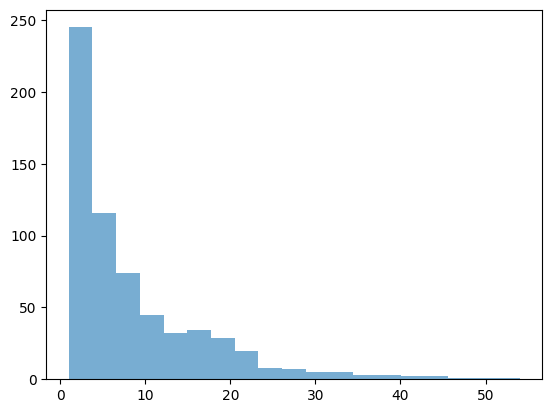

In [50]:
%matplotlib inline
trajectory_lengths = t.groupby('particle').size().reset_index(name='length')
_=plt.hist(trajectory_lengths['length'], 
    bins=np.linspace(trajectory_lengths['length'].min(),
                    trajectory_lengths['length'].max(), 
                    20), 
                    alpha=0.6)#density=True, color='blue',

In [15]:
pd.concat([df_plus, df_minus], ignore_index=True).to_csv(str(file_path.parents[1]) + r"\Defects\PlusAndMinusTM.csv")

,charge,x,y,x_ind,y_ind,ang1,ang2,ang3,frame
0,0.5,178.0,24.0,178,24,0.000000,NaN,NaN,0
1,0.5,1245.0,33.0,1245,33,0.691150,NaN,NaN,0
2,0.5,455.0,34.0,455,34,0.000000,NaN,NaN,0
3,0.5,1123.0,78.0,1123,78,-2.827433,NaN,NaN,0
4,0.5,1409.0,79.0,1409,79,2.136283,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...
10528,-0.5,120.0,1071.0,120,1071,-2.010619,1.884956,-0.062832,85
10529,-0.5,314.0,1081.0,314,1081,-0.125664,-2.073451,2.010619,85
10530,-0.5,1295.0,1086.0,1295,1086,1.947787,-0.125664,-1.947787,85
10531,-0.5,1403.0,1087.0,1403,1087,-2.073451,-0.188496,1.759292,85


# Defect dynamics time lapse

## Make dataframe with all defects and save as csv

In [ ]:
%matplotlib qt
PLOT = False
SAVE = True
SAVE_df = not PLOT
minushalf_df = pd.DataFrame([])
plushalf_df = pd.DataFrame([])

file_path = Path(image_list[0])

if PLOT:
    fig, ax = plt.subplots(1,1, figsize=(8,8))
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())


for i,im1 in enumerate(image_list[200:]):
    img1 = cv2.imread(im1)[:,:,0]
    ori, plushalf, minushalf = analyze_defects(img1, 25)
    frame_num = int(os.path.splitext(os.path.basename(im1))[0].split("Trans__")[-1])
    minushalf['frame'] = frame_num
    plushalf['frame'] = frame_num
    minushalf_df = pd.concat([minushalf_df, minushalf], ignore_index=True)
    plushalf_df = pd.concat([plushalf_df, plushalf], ignore_index=True)

    if PLOT:
        ax.clear() 
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_clahe = clahe.apply(img1)
        ax.imshow(img_clahe, cmap="gray")

        s = 15
        x = np.arange(0, img1.shape[1], s)
        y = np.arange(0, img1.shape[0], s)

        ax.quiver(x,y, #xx[::s,::s], yy[::s,::s],
            np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
            headaxislength=0, headwidth=0, headlength=0, 
            color='lawngreen', scale=60, pivot='mid', alpha=.7)

        alpha_half, scale_half = .9, 40    
        ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=6, alpha=1)
        ax.quiver(plushalf['x'], plushalf['y'], 
            np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
            headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

        ax.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=1)
        for j in range(3):
            ax.quiver(minushalf['x'], minushalf['y'], 
                np.cos(minushalf['ang'+str(j+1)]), -np.sin(minushalf['ang'+str(j+1)]), 
                headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
        
        # ----- Save Images with overlay of defects and director field  -----
        if SAVE and PLOT:
            save_path = os.path.join(
                str(file_path_path.parents[1]),
                'Nematic1',
                'frame_' + str(i) + ".png"
                )
            # break
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))

        break

    # ---------------- Save CSV ----------------
    # if (not i %50) and SAVE_df:  
    #     save_path = str(file_path.parents[1]) + r"\Defects\MinusHalf1.csv"
    #     os.makedirs(os.path.dirname(save_path), exist_ok=True)
    #     minushalf_df.to_csv(save_path)
    #     save_path = str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv"
    #     plushalf_df.to_csv(save_path)

    save_path = os.path.join(
            os.path.dirname(im1), 
            'Nematic', 
            os.path.splitext(os.path.basename(im1))[0]
            )
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cv2.imwrite(save_path + '_orient.tif', ori)
    # break

    progressBar(i, len(image_list[160:500]))

# if SAVE_df:
#     save_path = str(file_path.parents[1]) + r"\Defects\MinusHalf1.csv"
#     minushalf_df.to_csv(save_path)
#     save_path = str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv"
#     plushalf_df.to_csv(save_path)

In [ ]:
file_path = Path(image_list[0])

minushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\MinusHalf1.csv")
plushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv")

In [ ]:
import matplotlib

matplotlib.rc('axes', edgecolor='m')
plt.rcParams['xtick.color'] = 'm'
plt.rcParams['ytick.color'] = 'm'

file_path = Path(image_list[0])

frames = minushalf_df["frame"].unique()

fig, ax = plt.subplots(1,1, figsize=(11,11))
# ax.set_axis_off()
extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# plt.tight_layout()
white_frame = np.ones((2048,2048,3))

for i,f in enumerate(frames):
    
    minushalf = minushalf_df[minushalf_df["frame"]==f]
    plushalf = plushalf_df[plushalf_df["frame"]==f]
    
    alpha_half, scale_half = .9, 40   
    ax.clear() 
    ax.imshow(white_frame, "gray")
    ax.plot(plushalf['x'], plushalf['y'],'r.',markersize=6, alpha=1)
    # ax.quiver(plushalf['x'], plushalf['y'], 
    #     np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
    #     headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    ax.plot(minushalf['x'], minushalf['y'],'b.',markersize=6, alpha=1)
    # for i in range(3):
    #     ax.quiver(minushalf['x'], minushalf['y'], 
    #         np.cos(minushalf['ang'+str(i+1)]), -np.sin(minushalf['ang'+str(i+1)]), 
    #         headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)  

    save_path = os.path.join(
        str(file_path.parents[1]), 
        'Nematic2',
        'frame_' + str(f) + ".png"
        )
    # break
    ax.set_xlim([0, 2048])
    ax.set_ylim([0, 2048])
    # ax.set_box_aspect(1)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))  

    progressBar(i, len(frames))     
    # break



## Import CSVs

In [ ]:
image_list = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s6(120-919)\Raw\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

### Run TrackMate before proceeding!!!

In [ ]:
file_path = Path(image_list[0])
minushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\MinusHalf1.csv")
plushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv")

minushalf_TM = pd.read_csv(str(file_path.parents[1]) + r"\Defects\MinusTM_spots.csv", skiprows=[1,2,3])
plushalf_TM = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusTM_spots.csv", skiprows=[1,2,3])

first_frame = np.max([minushalf_df["frame"].min(), plushalf_df["frame"].min()]) # Validate this number in image folders
last_frame = np.min([minushalf_df["frame"].max(), plushalf_df["frame"].max()])   # Validate this number in image folders

print("  ////////    PLUS   //////////")
print([(plushalf_TM[plushalf_TM["FRAME"]==i]).shape for i in range(10)])
print([(plushalf_df[plushalf_df["frame"]==i+first_frame]).shape for i in range(10)])

print("\n ////////    MINUS   //////////")
print([(minushalf_TM[minushalf_TM["FRAME"]==i]).shape for i in range(10)])
print([(minushalf_df[minushalf_df["frame"]==i+first_frame]).shape for i in range(10)])

  ////////    PLUS   //////////
[(165, 20), (160, 20), (162, 20), (159, 20), (159, 20), (160, 20), (154, 20), (151, 20), (136, 20), (151, 20)]
[(165, 10), (160, 10), (162, 10), (159, 10), (159, 10), (160, 10), (154, 10), (151, 10), (136, 10), (151, 10)]

 ////////    MINUS   //////////
[(163, 20), (161, 20), (159, 20), (158, 20), (157, 20), (165, 20), (154, 20), (148, 20), (140, 20), (152, 20)]
[(163, 10), (161, 10), (159, 10), (158, 10), (157, 10), (165, 10), (154, 10), (148, 10), (140, 10), (152, 10)]


## Find shift and rescale

slope: 2.4182197403551995 | intercept: -161.3026999064075
slope: 2.4182197403551995 | intercept: -161.3026999064075
slope: 2.4181960229059363 | intercept: -161.3925871074263
-------  X  ------------
slope: 2.4176574553785266 | intercept: -153.3713347526516
slope: 2.4176574553785266 | intercept: -153.3713347526516
slope: 2.4178980977128597 | intercept: -153.43445137334828
-------  Y  ------------


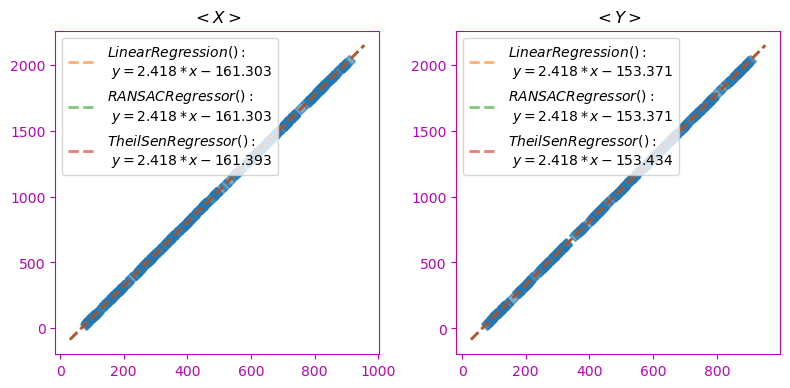

In [ ]:
from sklearn import linear_model

%matplotlib inline
frame = 1

fig, axs = plt.subplots(1,2,  figsize=(8,16))

dims = ("x", "y")
lrs = (
    linear_model.LinearRegression(), 
    linear_model.RANSACRegressor(), 
    linear_model.TheilSenRegressor()
    )

slope_intercept = {}

for ax,dd in zip(axs, dims):
    ave_slope, ave_intercept = 0, 0

    X = plushalf_TM["POSITION_"+dd.upper()][plushalf_TM["FRAME"]==frame].iloc[:].sort_values().values
    y = plushalf_df[dd][plushalf_df["frame"]==first_frame+frame].iloc[:]

    if dd=="y":
        # !!! insert image height (e.g. 2048)
        y = (2048 - y) # y- values are flipped
    y = y.sort_values().values

    ax.plot(X, y, "D", alpha=.6)

    for lr in lrs:
        lr.fit(X.reshape(-1, 1), y)
        try:
            slope = lr.estimator_.coef_[0]
            intercept = lr.estimator_.intercept_
        except:
            slope = lr.coef_[0]
            intercept = lr.intercept_

        # use prints to set the SLOPE and INTERCEP globals in the next cell
        print('slope:', slope, '| intercept:', intercept)

        # prdict for line
        line_X = np.arange(X.min()-50, X.max()+50)[:, np.newaxis]
        line_y = lr.predict(line_X)

        ax.plot(line_X, line_y, "--", linewidth=2, alpha=.6,
                label="$%s:$\n $y= %.3f *x %.3f$" %(lr, slope, intercept))   
         
        ave_slope += slope  
        ave_intercept += intercept

    ax.set_title("$< %s >$" %dd.upper())

    ax.set_box_aspect(1)
    ax.legend(loc='upper left')
    print("-------  %s  ------------" %dd.upper())

    slope_intercept[dd] = {"slope": ave_slope/len(lrs),
                             "intercept": ave_intercept/len(lrs)
                             }

    # ave_slope = ave_slope/len(lrs)
    # ave_intercept = ave_intercept/len(lrs)
plt.tight_layout()

### Validate shift and rescale

In [ ]:
image_list[0]

'C:\\Users\\victo\\Downloads\\SB_lab\\HBEC\\s4(120-919)\\Raw\\Trans__001.tif'

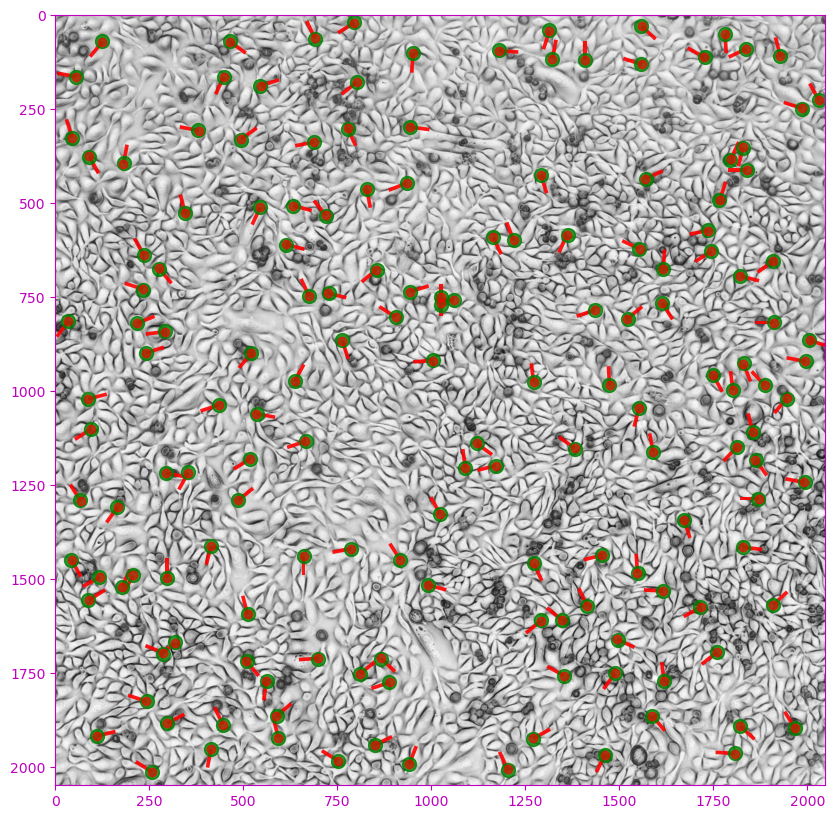

In [ ]:
%matplotlib inline
SLOPEx = slope_intercept["x"]["slope"]
INTERCEPTx = slope_intercept["x"]["intercept"]
SLOPEy = slope_intercept["y"]["slope"]
INTERCEPTy = slope_intercept["y"]["intercept"]
frame = 1

image_list_all = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s6(120-919)\Raw\*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame-1:1]
im1 = image_list[0]

file_path = Path(image_list[0])
plushalf_TM = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusTM_spots.csv", skiprows=[1,2,3])
plushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv")

# Apply Contrast Limited Adaptive Histogram Equalization
img1 = cv2.imread(im1)[:,:,0]
h_img, w_img = img1.shape
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(255-img_clahe, "gray")

x = plushalf_TM["POSITION_X"][plushalf_TM["FRAME"]==frame].iloc[:].values * SLOPEx + INTERCEPTx
y = h_img - (plushalf_TM["POSITION_Y"][plushalf_TM["FRAME"]==frame].iloc[:].values * SLOPEy + INTERCEPTy)
ax.plot(x, y,'go',markersize=10, alpha=.8)

alpha_half, scale_half = .9, 40  
p_df =  plushalf_df[plushalf_df["frame"]==first_frame+frame]
ax.plot(p_df['x'], p_df['y'],'ro',markersize=6, alpha=.6)
ax.quiver(p_df['x'], p_df['y'], 
    np.cos(p_df['ang1']), -np.sin(p_df['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

### Apply angle information data to TrackMate DataFrame

In [ ]:
%matplotlib qt
# SLOPEx = 2.2020369696888773
# INTERCEPTx = -153.5892752236614
# SLOPEy = 2.589611169431241
# INTERCEPTy = -152.43827493084723


minushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\MinusHalf1.csv")
plushalf_df = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusHalf1.csv")

minushalf_TM = pd.read_csv(str(file_path.parents[1]) + r"\Defects\MinusTM_spots.csv", skiprows=[1,2,3])
plushalf_TM = pd.read_csv(str(file_path.parents[1]) + r"\Defects\PlusTM_spots.csv", skiprows=[1,2,3])

first_frame = minushalf_df["frame"].min() # Validate this number in image folders

plushalf_TM["x_img"] = plushalf_TM["POSITION_X"] * SLOPEx + INTERCEPTx
plushalf_TM["y_img"] = h_img - (plushalf_TM["POSITION_Y"] * SLOPEy + INTERCEPTy)
minushalf_TM["x_img"] = minushalf_TM["POSITION_X"] * SLOPEx + INTERCEPTx
minushalf_TM["y_img"] = h_img - (minushalf_TM["POSITION_Y"] * SLOPEy + INTERCEPTy)

In [ ]:
# find same dots and check
dfs_TM = [plushalf_TM, minushalf_TM]
dfs_ori = [plushalf_df, minushalf_df]

for df_TM, df_ori in zip(dfs_TM, dfs_ori):
    xy_ori = np.array([df_ori["x"], df_ori["y"]]).T
    xy_TM = np.array([df_TM["x_img"].values, df_TM["y_img"].values]).T
    _,idx = center_pairs(
        xy_ori, #Long Array
        xy_TM #Short Array
        ) 
    # break
    print(xy_ori[idx[100:103]],'\n', xy_TM[100:103],'\n', df_ori[['x', 'y']].loc[idx[100:103]].values)
    print("--------------")

    # replace and add angles
    df_TM[['x_img1','y_img1','ang1','ang2','ang3','charge']] =  df_ori[['x', 'y','ang1','ang2','ang3','charge']].iloc[idx[:]].values


[[1208.  301.]
 [ 372.  299.]
 [2035.  318.]] 
 [[1207.37177641  301.05402436]
 [ 373.0886935   298.63628715]
 [2034.3150134   317.97818851]] 
 [[1208.  301.]
 [ 372.  299.]
 [2035.  318.]]
--------------
[[ 202. 1925.]
 [1442. 1912.]
 [1210. 1909.]] 
 [[ 201.39565325 1925.77373779]
 [1441.93832436 1911.26731177]
 [1209.78998825 1908.84957503]] 
 [[ 202. 1925.]
 [1442. 1912.]
 [1210. 1909.]]
--------------


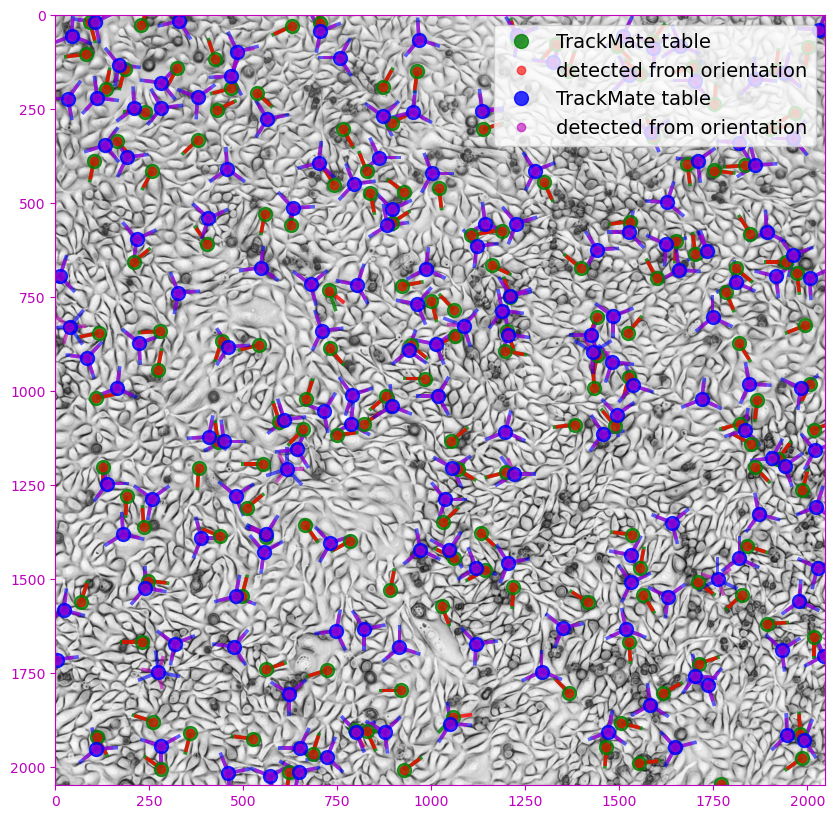

In [ ]:
# test replaced values
%matplotlib inline
frame = 5
last_frame = first_frame + plushalf_TM.FRAME.max()

image_list_all = glob.glob(r"C:\Users\victo\Downloads\SB_lab\HBEC\s6(120-919)\Raw\*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())

image_list = image_list_all[first_frame-1:last_frame-1:1]
im1 = image_list[frame]

# Apply Contrast Limited Adaptive Histogram Equalization
img1 = cv2.imread(im1)[:,:,0]
h_img, w_img = img1.shape
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(255-img_clahe, "gray")

# +1/2
idx = plushalf_TM["FRAME"]==frame
ax.plot(plushalf_TM["x_img1"][idx],
        plushalf_TM["y_img1"][idx],'go',
        markersize=10, alpha=.8, label="TrackMate table")
ax.quiver(plushalf_TM['x_img1'][idx], plushalf_TM['y_img1'][idx], 
    np.cos(plushalf_TM['ang1'][idx]), -np.sin(plushalf_TM['ang1'][idx]), 
    headaxislength=0, headwidth=0, headlength=0, color='g', scale=35, alpha=.8)        

p_df =  plushalf_df[plushalf_df["frame"]==first_frame+frame]
ax.plot(p_df['x'], p_df['y'],'ro',markersize=6, alpha=.6, label="detected from orientation")
ax.quiver(p_df['x'], p_df['y'], 
    np.cos(p_df['ang1']), -np.sin(p_df['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=40, alpha=.8)

# -1/2
idx = minushalf_TM["FRAME"]==frame
ax.plot(minushalf_TM["x_img1"][idx],
        minushalf_TM["y_img1"][idx],'bo',
        markersize=10, alpha=.8, label="TrackMate table")
for i in range(3):
    ax.quiver(minushalf_TM["x_img1"][idx], minushalf_TM["y_img1"][idx], 
        np.cos(minushalf_TM['ang'+str(i+1)][idx]), -np.sin(minushalf_TM['ang'+str(i+1)][idx]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=35, alpha=.6)    

m_df =  minushalf_df[minushalf_df["frame"]==first_frame+frame]
ax.plot(m_df['x'], m_df['y'],'mo',markersize=6, alpha=.6, label="detected from orientation")
for i in range(3):
    ax.quiver(m_df["x"], m_df["y"], 
        np.cos(m_df['ang'+str(i+1)][idx]), -np.sin(m_df['ang'+str(i+1)][idx]), 
        headaxislength=0, headwidth=0, headlength=0, color='m', scale=45, alpha=.6)    

ax.legend(loc='upper right', fontsize=14)

In [ ]:
# Join TrackMate tabels for +1/2 and -1/2
pd.concat([plushalf_TM, minushalf_TM]).to_csv(str(file_path.parents[1]) + r"\Defects\PlusAndMinusTM.csv")

# Start Here Find Pairs

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Defects\PlusAndMinusTM.csv")
plus_minus_df.tail()

,Unnamed: 0,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,...,CONTRAST_CH1,SNR_CH1,x_img,y_img,x_img1,y_img1,ang1,ang2,ang3,charge
93581,46890,ID340198,340198,4380.0,79.719513,534.0,878.0,0.0,339.0,339,...,0.916894,1.575584,1144.131149,13.135322,1145.0,13.0,-3.078761,1.193805,-1.130973,-0.5
93582,46891,ID340193,340193,4313.0,81.421516,164.0,839.0,0.0,339.0,339,...,0.973672,1.625018,222.609035,110.270194,222.0,111.0,2.324779,-1.822124,0.376991,-0.5
93583,46892,ID340192,340192,NaN,81.421516,765.0,836.0,0.0,339.0,339,...,0.973672,1.625018,1719.459819,117.742108,1720.0,119.0,-2.953097,-1.068142,1.256637,-0.5
93584,46893,ID340195,340195,NaN,81.421516,754.0,855.0,0.0,339.0,339,...,0.973672,1.625018,1692.063216,70.419990,1693.0,70.0,-1.507964,0.125664,2.199115,-0.5
93585,46894,ID340194,340194,4312.0,81.421516,683.0,854.0,0.0,339.0,339,...,0.973672,1.625018,1515.230594,72.910628,1516.0,72.0,-2.576106,-0.691150,1.319469,-0.5


In [ ]:
ang = np.arange(0,10,.1)
mod_ang = ang % (2*np.pi)
plt.plot(ang, mod_ang)
plt.plot(ang, np.unwrap(mod_ang, period=(2*np.pi)))

<AxesSubplot: xlabel='x_img1', ylabel='y_img1'>

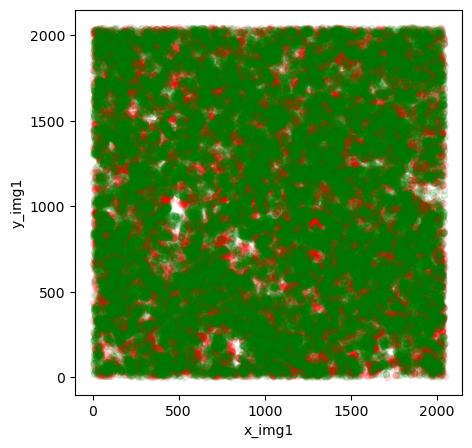

In [ ]:
%matplotlib inline
fig, ax1 = plt.subplots(1,1, figsize=(5,5))
plus_minus_df[plus_minus_df.charge==.5].plot.scatter("x_img1","y_img1", ax=ax1,c="r", alpha=.1)
plus_minus_df[plus_minus_df.charge==-.5].plot.scatter("x_img1","y_img1", ax=ax1,c="g", alpha=.1)

## Number of Defects over time

Text(0.5, 1.0, '$Absolute ~Charge ~of ~\\pm 1/2 ~defects$')

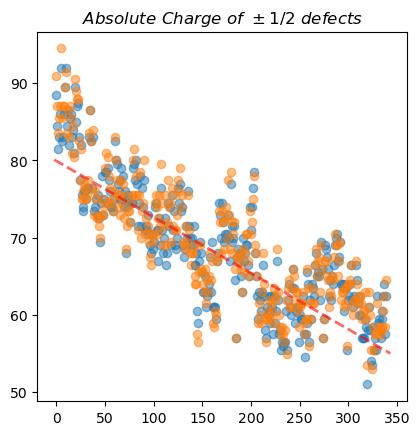

In [ ]:
%matplotlib inline
charge_av = []
charge_std = []
charge_p = []
charge_n = []
for frame in plus_minus_df.FRAME.unique():
    # charge_av.append(plus_minus_df.charge[plus_minus_df.FRAME==frame].sum())
    # charge_std.append(plus_minus_df.charge[plus_minus_df.FRAME==frame].std())
    charge_p.append(plus_minus_df.charge[(plus_minus_df.charge==.5)&(plus_minus_df.FRAME==frame)].sum())
    charge_n.append(plus_minus_df.charge[~(plus_minus_df.charge==.5)&(plus_minus_df.FRAME==frame)].sum())

charge_av = np.array(charge_av)
charge_std = np.array(charge_std)
# plt.plot(plus_minus_df.FRAME.unique(), charge_av, "o")
# plt.fill_between(plus_minus_df.FRAME.unique(), 
#                 charge_av - charge_std, 
#                 charge_av + charge_std, 
#                 color=color, alpha=.2) 
plt.plot(plus_minus_df.FRAME.unique(), charge_p, "o", alpha=.5)
plt.plot(plus_minus_df.FRAME.unique(), np.abs(charge_n), "o", alpha=.5)
plt.gca().set_box_aspect(1)


from sklearn import linear_model
lr = linear_model.TheilSenRegressor()
X = np.array(plus_minus_df.FRAME.unique()).reshape(-1, 1)
y = np.array(charge_p)

lr.fit(X, y)
line_X = np.arange(X.min()-2, X.max()+5)[:, np.newaxis]
line_y = lr.predict(line_X)
plt.plot(line_X, line_y, "--r", linewidth=2, alpha=.6)   
plt.title(r"$Absolute ~Charge ~of ~\pm 1/2 ~defects$")
        

In [ ]:
msd_plus_df = msd_from_df(plus_minus_df[plus_minus_df.charge==.5],"x_img1","x_img1","FRAME","TRACK_ID")
msd_minus_df = msd_from_df(plus_minus_df[plus_minus_df.charge==-.5],"x_img1","x_img1","FRAME","TRACK_ID")

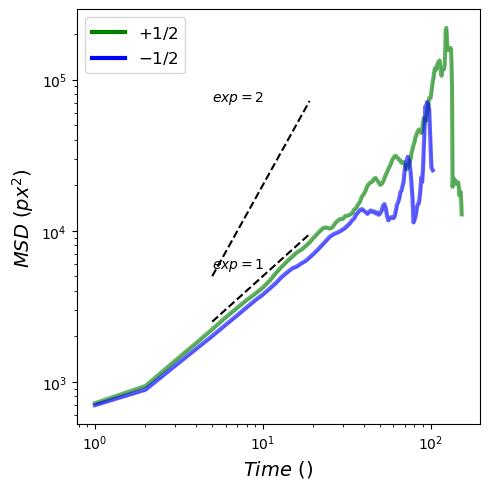

In [ ]:
%matplotlib inline
fig, ax2 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 1

for msd_df,color in zip([msd_plus_df, msd_minus_df], ["g","b"]):

    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax2.plot(msd_df.FRAME, msd_df["ave"], "-", color=color, alpha=.6, linewidth=3)
    ax2.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=color, alpha=.2) 


ax2.plot([0,0],[0,0], "-", color="g", linewidth=3, label=r"$+1/2$")
ax2.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(5, 20, 1)
ax2.plot(xref, 2e2*xref**2, "--k", xref, .5e3*xref**1,"--k")
ax2.text(xref[0], 2e2*xref[-1]**2, r"$exp=2$", )
ax2.text(xref[0], .3e3*xref[-1]**1, r"$exp=1$")
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r"$Time ~()$", fontsize=14); ax2.set_ylabel(r"$MSD ~(px^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()

In [ ]:
fig.savefig(r"C:\Users\victo\OneDrive - BGU\Presentations\Images\HBEC MSD.svg")

In [ ]:
# plus_minus_df["angm_ave"] = circmean(plus_minus_df[["ang1","ang2","ang2"]], high=2/3*np.pi, axis=1)
plus_minus_df["angm_ave"] = plus_minus_df["ang1"] % (2/3*np.pi)
plus_minus_df1 = plus_minus_df[["ang1","angm_ave","charge","FRAME","TRACK_ID"]]

msd_plus_df = ang_msd_from_df(plus_minus_df[(plus_minus_df.charge==.5)&(plus_minus_df.FRAME>10)],
                              "ang1","FRAME","TRACK_ID", minimal_track=20)
msd_minus_df = ang_msd_from_df(plus_minus_df1[(plus_minus_df1.charge==-.5)&(plus_minus_df.FRAME>10)],
                               "angm_ave","FRAME","TRACK_ID",period=2/3*np.pi, minimal_track=20)


# msd_plus_df = msd_from_df(plus_minus_df[plus_minus_df.charge==.5],"ang1","ang1","FRAME","TRACK_ID",minimal_track=10)
# msd_minus_df = msd_from_df(plus_minus_df1[plus_minus_df1.charge==-.5],"angm_ave","angm_ave","FRAME","TRACK_ID")

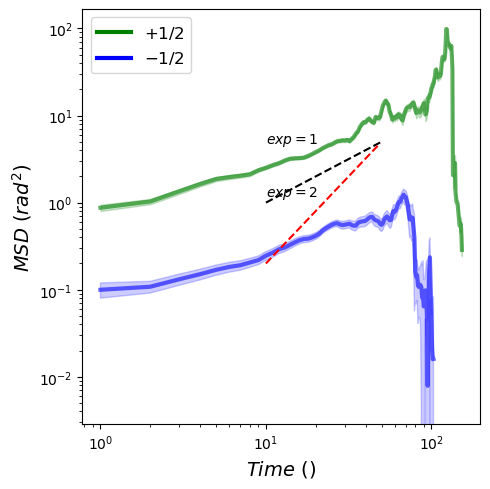

In [ ]:
%matplotlib inline
fig, ax2 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 1
 
for msd_df,color in zip([msd_plus_df, msd_minus_df], ["g","b"]):

    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax2.plot(msd_df.FRAME, msd_df["ave"], "-", color=color, alpha=.6, linewidth=3)
    ax2.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=color, alpha=.2) 
    # TODO check the "count" 
    # break


ax2.plot([0,0],[0,0], "-", color="g", linewidth=3, label=r"$+1/2$")
ax2.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(10, 50, 1)
ax2.plot(xref, 1e-1*xref**1, "--k", xref, 2e-3*xref**2, "--r",)
ax2.text(xref[0], 1e-1*xref[-1]**1, r"$exp=1$")
ax2.text(xref[0], .5e-3*xref[-1]**2, r"$exp=2$")
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r"$Time ~()$", fontsize=14); ax2.set_ylabel(r"$MSD ~(rad^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()